In [1]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [2]:
%%R
# to create a Conda environment that can be used to run the package
# conda create -n r_test -y r-essentials r-devtools

# to install the rwwa package
devtools::install_github("clairbarnes/rwwa")

# load package containing functions
library(rwwa)

Using GitHub PAT from the git credential store.
Skipping install of 'rwwa' from a github remote, the SHA1 (bb2ba069) has not changed since last install.
  Use `force = TRUE` to force installation
Loading required package: extRemes
Loading required package: Lmoments
Loading required package: distillery

Attaching package: 'extRemes'

The following objects are masked from 'package:stats':

    qqnorm, qqplot

Loading required package: plyr

Attaching package: 'plyr'

The following object is masked from 'package:distillery':

    is.formula

Loading required package: copula
Loading required package: MASS


In [ ]:
%%R

install.packages(c("dplyr", "tidyr", "lubridate", "zoo"))

library(dplyr)
library(tidyr)
library(lubridate)
library(zoo)

# Read the CSV file, similar to pandas.read_csv()
gmst <- read.csv(
    '../data/gmst.csv',
    na.strings = c("****", "***"),  # same as na_values
    row.names = 1,                  # same as index_col=0
    skip = 1,                       # same as skiprows=1
    comment.char = "#"              # same as comment="#"
)

# Convert rownames (years) to a numeric vector
years <- as.numeric(rownames(gmst))

# Initialize empty list to store each month's data
gmst_list <- list()

for (i in 1:12) {
  gmst_list[[i]] <- data.frame(
    valid_time = as.Date(paste(years, i, "01", sep = "-")),
    gmst = as.numeric(gmst[[i]])
  )
}

# Combine all months into a single data frame
gmst_monthly <- bind_rows(gmst_list) %>%
  arrange(valid_time) %>%
  drop_na(gmst)  # remove rows with NA in gmst_value

# Optional: reset row names
rownames(gmst_monthly) <- NULL

# Apply rolling mean
gmst_rolled <- rollapply(
  gmst_monthly$gmst,
  width = 48,          # window size
  FUN = mean,
  na.rm = TRUE,        # ignore NA values
  partial = TRUE,      # similar to min_periods
  align = "center"     # center the window
)

# turn back int df
gmst_rolled <- data.frame(
  valid_time = gmst_monthly$valid_time,
  gmst = gmst_rolled
)

# Extract the year from the datetime
gmst_rolled <- gmst_rolled %>%
  mutate(year = year(valid_time))  # create a year column

# Compute the mean for each year
gmst_yearly <- gmst_rolled %>%
  group_by(year) %>%
  summarise(
    gmst = mean(gmst, na.rm = TRUE)  # ignore NA values
  ) %>%
  ungroup()

gmst_yearly <- gmst_yearly %>%
    filter(year >= 1970 & year <= 2024)

gmst_print <- gmst_rolled %>%
    filter(year(valid_time) >= 1970 & year(valid_time) <= 2024)

# Preview
gmst_print

# A tibble: 55 x 2
    year     gmst
   <dbl>    <dbl>
 1  1970 -0.0139 
 2  1971  0.0303 
 3  1972  0.0104 
 4  1973  0.0219 
 5  1974  0.0117 
 6  1975 -0.00611
 7  1976  0.0215 
 8  1977  0.0430 
 9  1978  0.131  
10  1979  0.186  
# i 45 more rows
# i Use `print(n = ...)` to see more rows


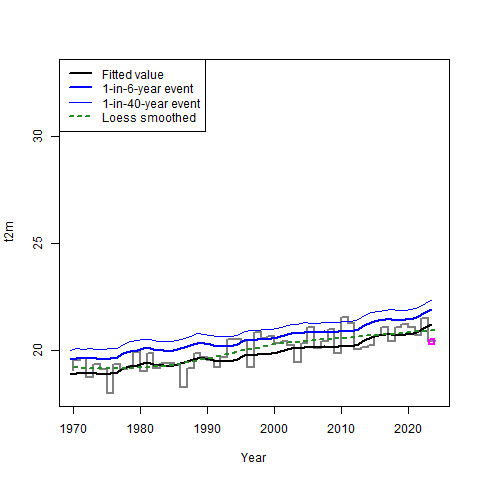

In [52]:
%%R

df <- read.csv("../data/gmst_t2m.csv")

mdl <- fit_ns(dist = "gev", type = "shift", data = df, varnm = "t2m", covnm = "gmst", lower = F, ev_year = 2024)

# the factual climate should have the GMST of the year in which the event occurred
cov_factual <- data.frame(gmst = df$gmst[df$year == 2024])

# the counterfactual climate can represent any alternative climate (WWA always uses a preindustrial climate, 1.3C cooler than the present)
cov_counterfactual <- data.frame(gmst = df$gmst[df$year == 2024] - 1.3)

# what does the fitted trend look like over time?
# `add_loess = T` will add a nonparametric smoother - use this to check whether the fitted model captures the observed trend
plot_trend(mdl, add_loess = T, ylim = c(18,33))